# Notebook 1: Data Loading & Exploratory Data Analysis (Regression)

## California Housing Prices

**Goal**: Predict the median house value for California districts based on features like income, house age, and location.

This is the first step in our Data Science Lifecycle:
1. **Data Loading** ← we are here
2. **Exploratory Data Analysis (EDA)** ← we are here
3. Preprocessing & Feature Engineering
4. Model Training & Evaluation
5. Model Comparison & Insights

---

### Why this dataset?
- It's a classic regression problem used in many ML courses
- Real-world data from the 1990 California census
- Has enough features to be interesting, but not overwhelming
- Requires some preprocessing (good for learning!)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look nicer
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# show all columns in dataframes
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


## 2. Load the Data

We're loading the California Housing dataset from a local CSV file.
This dataset was originally collected from the 1990 US Census.

In [2]:
# load the dataset
df = pd.read_csv('../data/california_housing.csv')

# quick look at the first few rows
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset shape: 20640 rows, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### What do these columns mean?

| Column | Description |
|--------|------------|
| MedInc | Median income in the block group (in tens of thousands) |
| HouseAge | Median house age in the block group |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block group population |
| AveOccup | Average number of household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |
| **MedHouseVal** | **Median house value (TARGET - what we want to predict)** |

## 3. Basic Data Inspection

Before doing anything fancy, let's understand what we're working with.
This is like reading the ingredients list before cooking.

In [3]:
# data types and non-null counts
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Info ---')
df.info()

--- Data Types ---
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


In [5]:
# basic statistics
# this gives us a quick overview of the distribution of each column
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### Key observations from `.describe()`:
- **MedInc** ranges from ~0.5 to ~15 (tens of thousands of dollars)
- **HouseAge** goes up to 52 (likely capped)
- **AveRooms** and **AveBedrms** have some very high values (possible outliers)
- **MedHouseVal** (our target) is capped at 5.0 ($500,000)
- No missing values — that's nice!

## 4. Exploratory Data Analysis (EDA)

Now let's actually *look* at the data. EDA is about asking questions:
- What does the target variable look like?
- Are there outliers?
- Which features seem related to the target?
- Are any features correlated with each other?

### 4.1 Target Variable Distribution

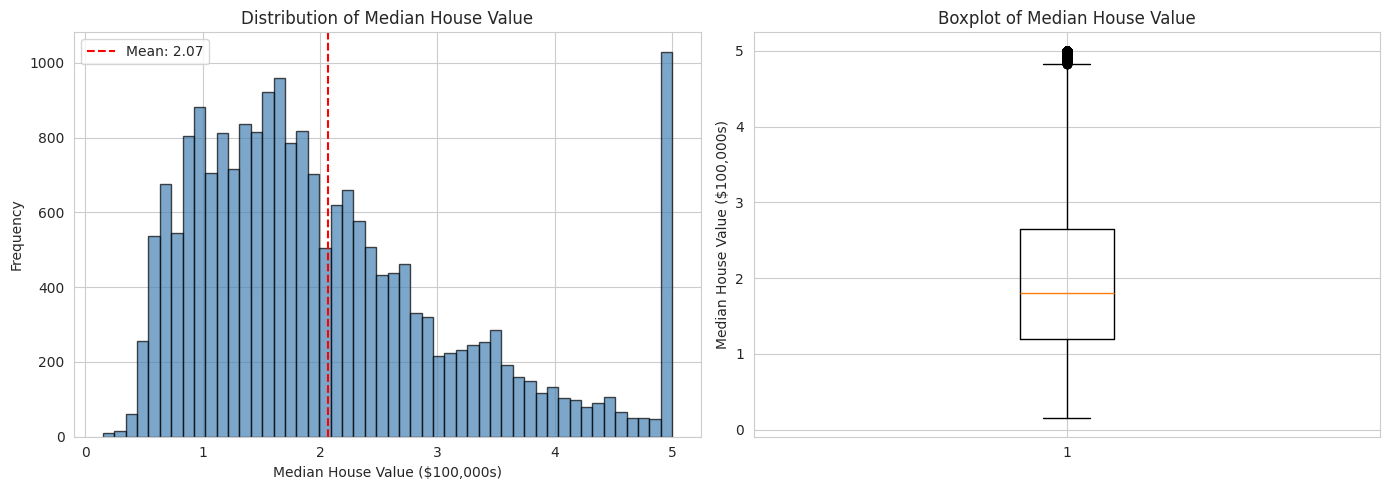

Notice the spike at 5.0 — the values are capped at $500,000


In [6]:
# let's see how house prices are distributed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0].legend()

# boxplot
axes[1].boxplot(df['MedHouseVal'], vert=True)
axes[1].set_title('Boxplot of Median House Value')
axes[1].set_ylabel('Median House Value ($100,000s)')

plt.tight_layout()
plt.savefig('../images/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Notice the spike at 5.0 — the values are capped at $500,000')

### 4.2 Feature Distributions

Let's look at how each feature is distributed. This helps us spot:
- Skewed distributions (might need transformation)
- Outliers (might need handling)
- Unusual patterns

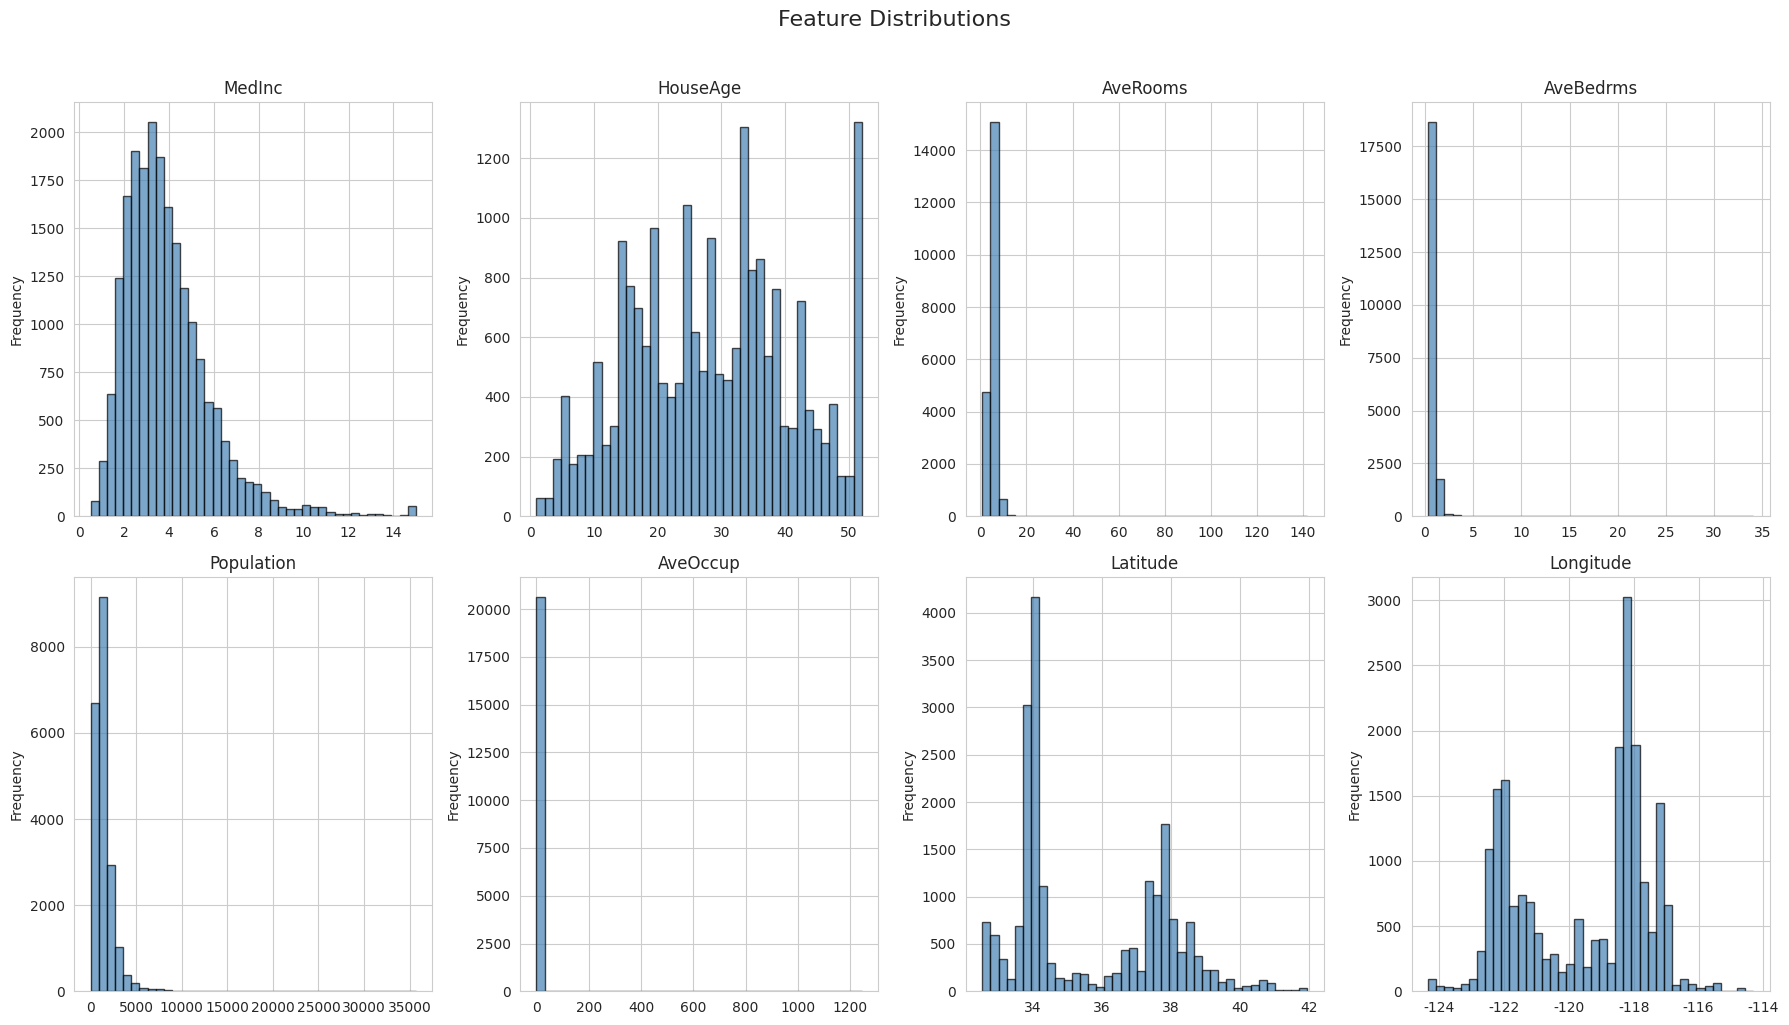

In [7]:
# plot histograms for all features
features = df.columns.drop('MedHouseVal')

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Correlation Analysis

Correlation tells us how strongly two variables are related.
- Values close to **+1** = strong positive relationship
- Values close to **-1** = strong negative relationship
- Values close to **0** = weak or no relationship

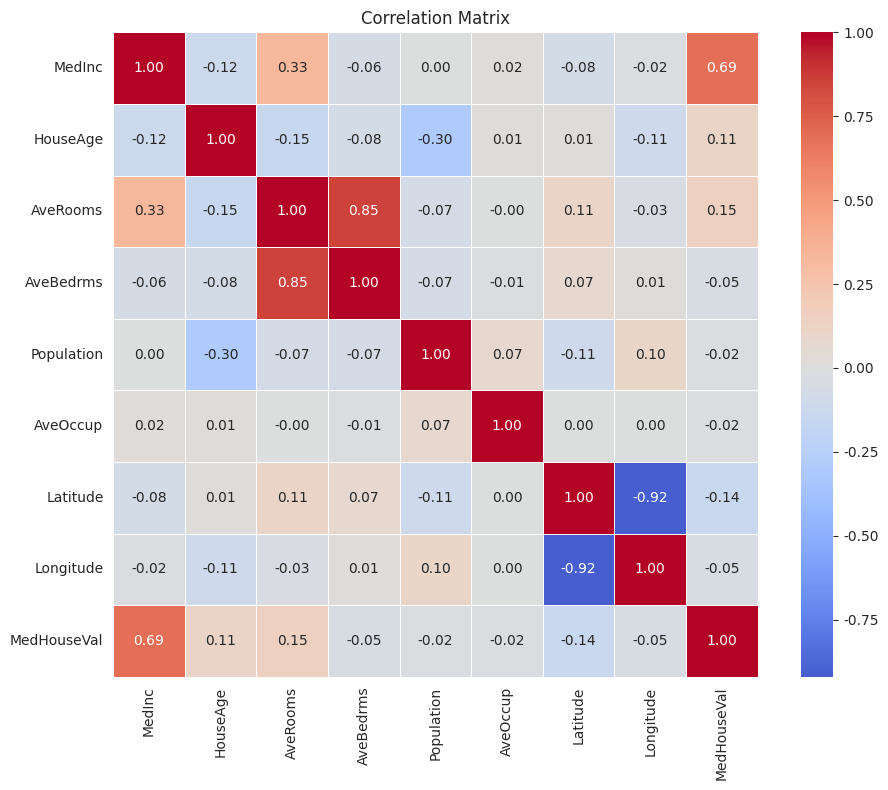

Correlation with MedHouseVal (target):
MedHouseVal    1.00
MedInc         0.69
AveRooms       0.15
HouseAge       0.11
Population    -0.02
AveOccup      -0.02
AveBedrms     -0.05
Longitude     -0.05
Latitude      -0.14
Name: MedHouseVal, dtype: float64


In [8]:
# correlation matrix
corr_matrix = df.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../images/01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# which features correlate most with our target?
print('Correlation with MedHouseVal (target):')
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))

### 4.4 Scatter Plots: Features vs Target

Let's see how each feature relates to house prices visually.

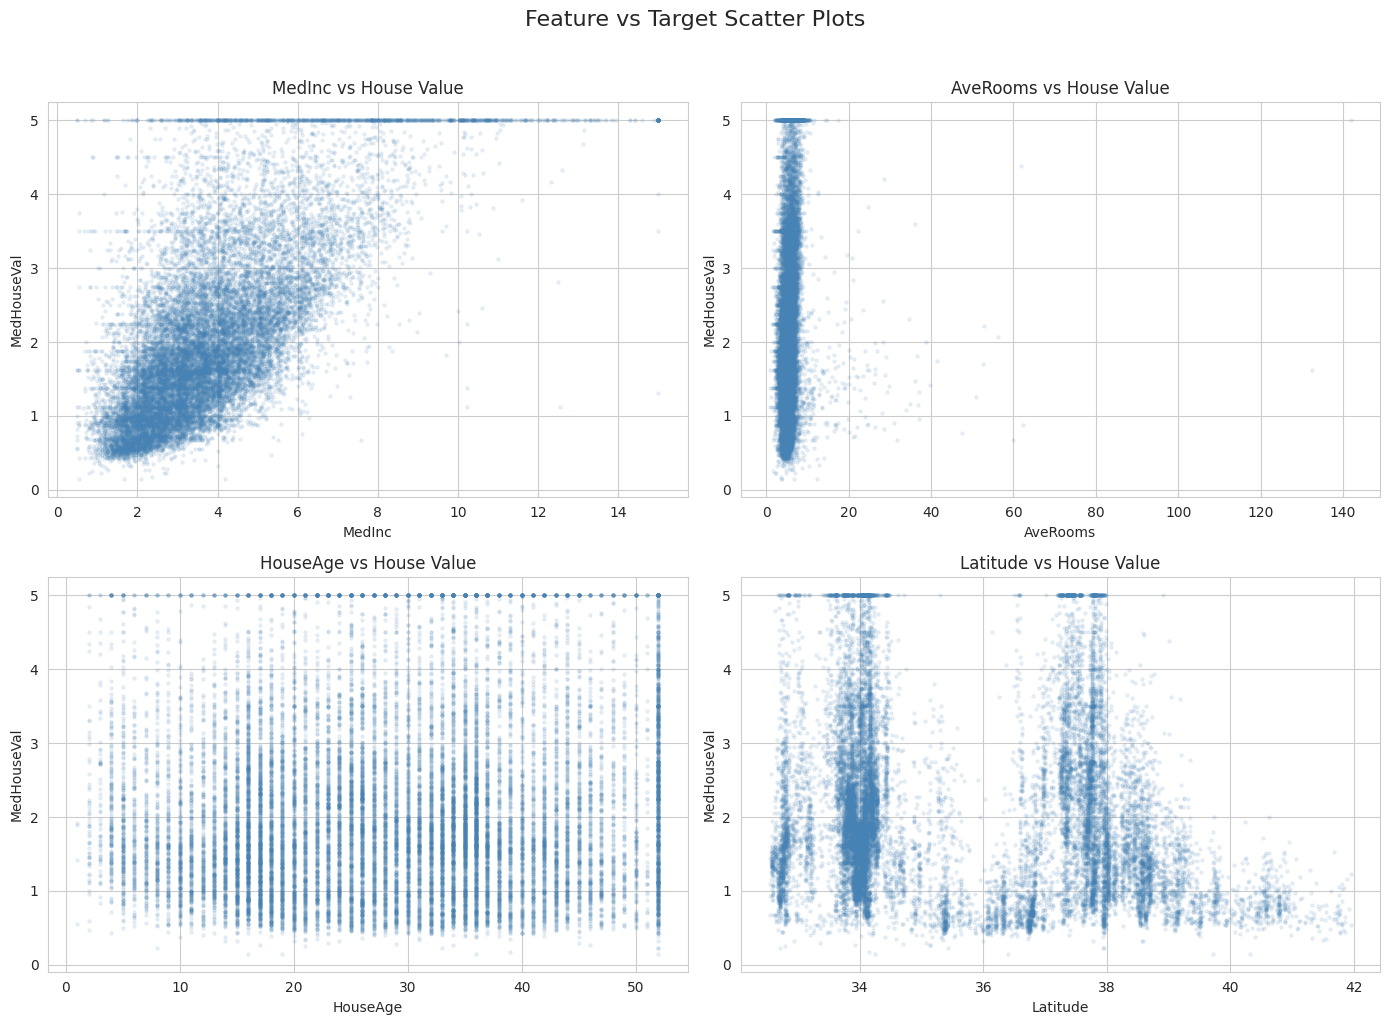

In [9]:
# scatter plots of top features vs target
top_features = ['MedInc', 'AveRooms', 'HouseAge', 'Latitude']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['MedHouseVal'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'{col} vs House Value')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/01_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Geographic Visualization

Since we have latitude and longitude, let's plot the data on a map.
This is one of the coolest things about this dataset!

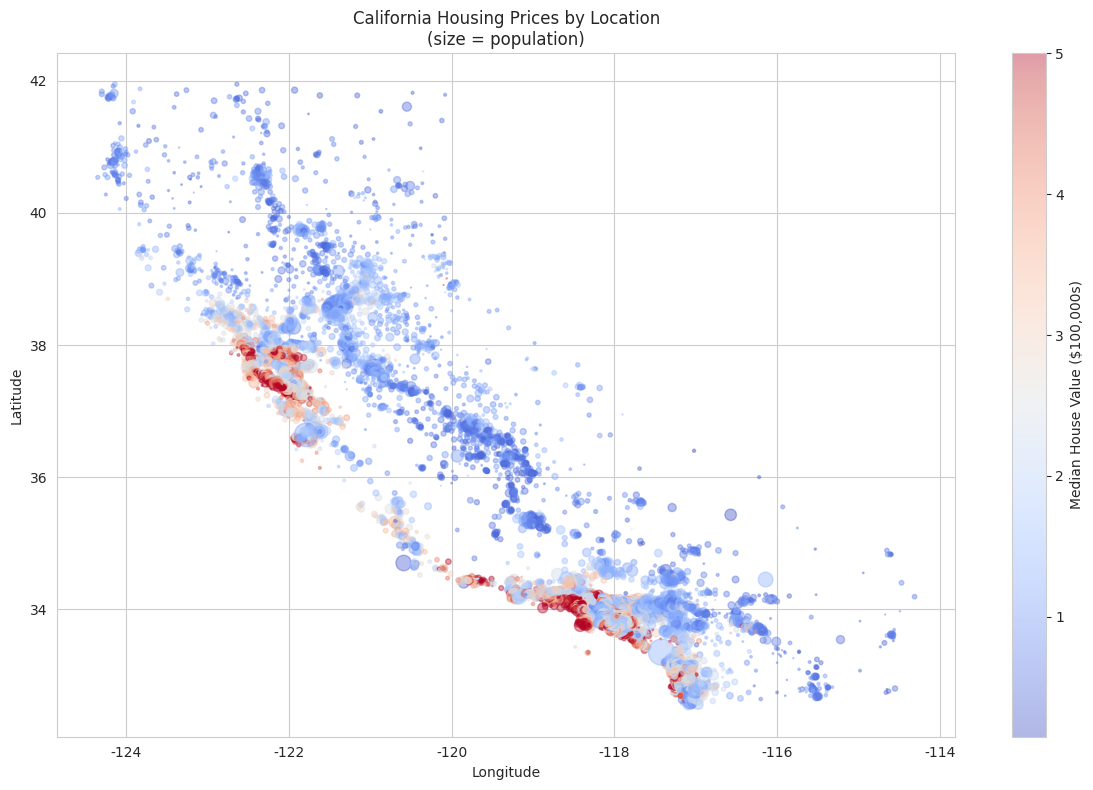

Red = expensive areas (coastal cities like SF, LA)
Blue = cheaper areas (inland)


In [10]:
# geographic plot of house prices
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'], 
                      c=df['MedHouseVal'], cmap='coolwarm',
                      alpha=0.4, s=df['Population']/100)
plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location\n(size = population)')
plt.tight_layout()
plt.savefig('../images/01_geo_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Red = expensive areas (coastal cities like SF, LA)')
print('Blue = cheaper areas (inland)')

### 4.6 Outlier Detection

Let's check for extreme values that might cause problems during modeling.

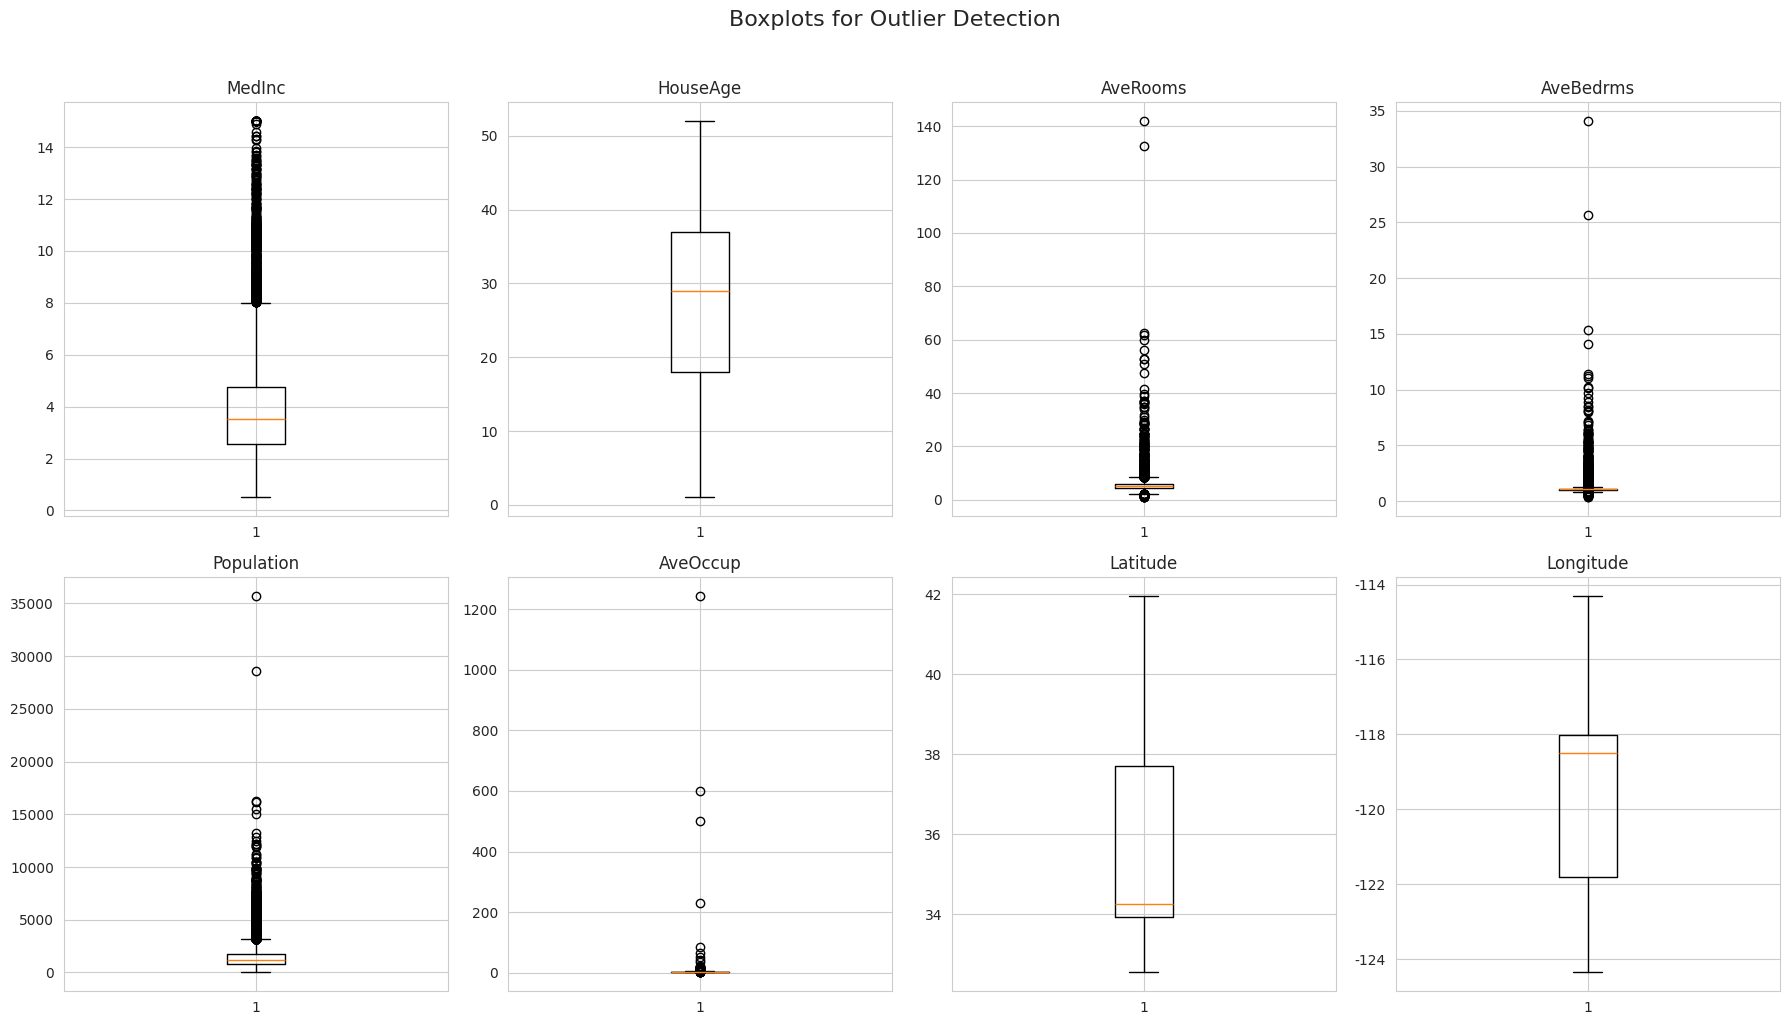

AveRooms, AveBedrms, AveOccup, and Population have noticeable outliers.
We will handle these in the preprocessing notebook.


In [11]:
# boxplots for all features to spot outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/01_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('AveRooms, AveBedrms, AveOccup, and Population have noticeable outliers.')
print('We will handle these in the preprocessing notebook.')

## 5. Key Takeaways from EDA

Here's what we learned about our data:

1. **No missing values** — great, but we still need to preprocess
2. **MedInc (Median Income)** is the strongest predictor of house value (correlation = 0.69)
3. **Location matters** — coastal areas are more expensive
4. **Target is capped at 5.0** — some houses are worth more but the data caps at $500K
5. **Outliers exist** in AveRooms, AveBedrms, AveOccup, and Population
6. **Some features are skewed** — might benefit from log transformation

### Next Steps
In the next notebook, we'll:
- Handle outliers
- Scale features
- Engineer new features if useful
- Prepare the data for modeling